<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/Sonar_Mines_vs_Rocks_case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Load dataset
df = pd.read_csv("sonardataset.csv")


In [4]:
df.shape

(208, 61)

In [5]:
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [6]:
# Check class distribution
print(df["Y"].value_counts())

Y
M    111
R     97
Name: count, dtype: int64


In [7]:
# Separate features and target
X = df.drop("Y", axis=1)
y = df["Y"]


In [8]:
# Encode labels (M=1, R=0)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [9]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
# Build ANN
model = Sequential([
    Dense(32, input_dim=60, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")  # binary classification
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Compile model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5964 - loss: 0.7249 - val_accuracy: 0.6190 - val_loss: 0.6833
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7169 - loss: 0.5924 - val_accuracy: 0.6429 - val_loss: 0.6055
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7771 - loss: 0.5031 - val_accuracy: 0.6429 - val_loss: 0.5498
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8434 - loss: 0.4377 - val_accuracy: 0.7143 - val_loss: 0.4984
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8735 - loss: 0.3824 - val_accuracy: 0.7381 - val_loss: 0.4629
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8916 - loss: 0.3351 - val_accuracy: 0.7619 - val_loss: 0.4284
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9217 - loss: 0.2958 - val_accuracy: 0.7857 - val_loss: 0.4020
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9398 - loss: 0.2606 - val_accuracy: 0.7619 - val_

In [13]:
# Predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


In [14]:
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8333333333333334
Precision: 0.8823529411764706
Recall: 0.75
F1 Score: 0.8108108108108109


In [15]:
# Detailed report
print(classification_report(y_test, y_pred, target_names=["Rock","Mine"]))

              precision    recall  f1-score   support

        Rock       0.80      0.91      0.85        22
        Mine       0.88      0.75      0.81        20

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.83        42
weighted avg       0.84      0.83      0.83        42



In [16]:
# Experiment with deeper network
model2 = Sequential([
    Dense(64, input_dim=60, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss="binary_crossentropy", metrics=["accuracy"])

history2 = model2.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test), verbose=1)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7169 - loss: 0.6107 - val_accuracy: 0.7857 - val_loss: 0.5613
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8434 - loss: 0.4752 - val_accuracy: 0.8571 - val_loss: 0.4706
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8735 - loss: 0.3793 - val_accuracy: 0.8571 - val_loss: 0.3877
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9157 - loss: 0.3049 - val_accuracy: 0.8571 - val_loss: 0.3336
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9337 - loss: 0.2461 - val_accuracy: 0.8810 - val_loss: 0.3138
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9639 - loss: 0.1948 - val_accuracy: 0.8810 - val_loss: 0.2787
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9699 - loss: 0.1502 - val_accuracy: 0.8810 - val_loss: 0.2796
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9880 - loss: 0.1159 - val_accuracy: 0.9048 - val_loss: 0.

In [17]:
# Evaluate tuned model
y_pred2 = (model2.predict(X_test) > 0.5).astype("int32")

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred2))
print("Tuned Model F1 Score:", f1_score(y_test, y_pred2))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Tuned Model Accuracy: 0.8809523809523809
Tuned Model F1 Score: 0.8648648648648649


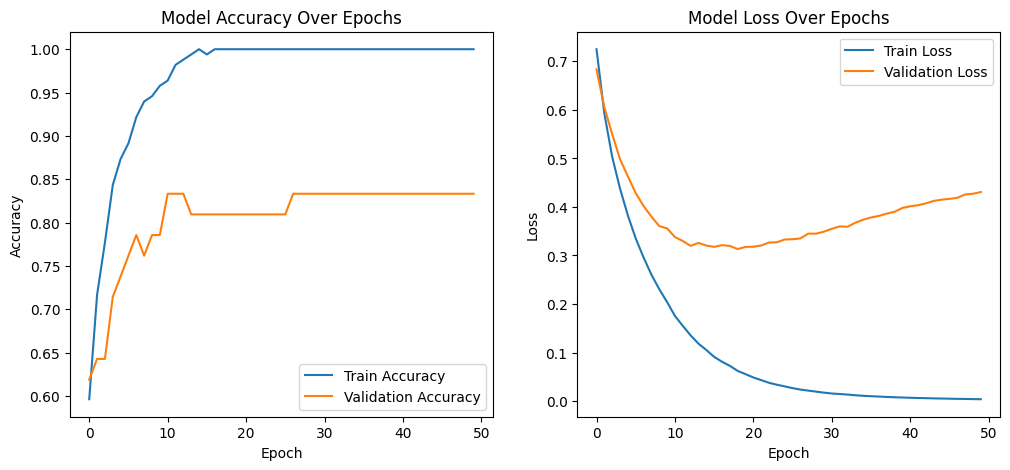

In [18]:
# Plot training & validation accuracy values
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

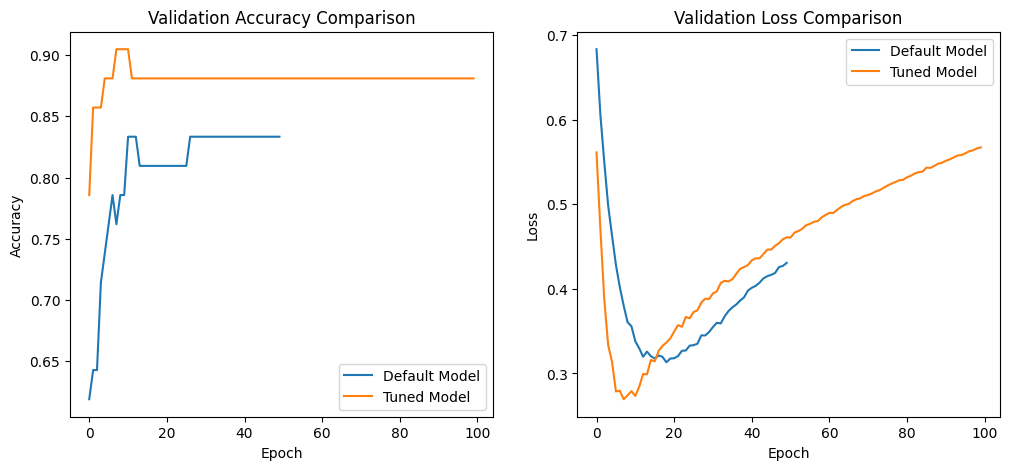

In [19]:
# Accuracy comparison
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['val_accuracy'], label='Default Model')
plt.plot(history2.history['val_accuracy'], label='Tuned Model')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss comparison
plt.subplot(1,2,2)
plt.plot(history.history['val_loss'], label='Default Model')
plt.plot(history2.history['val_loss'], label='Tuned Model')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()